# Demand Forecasting
This notebook builds two models:
1. Overall demand forecasting
2. Specialty specific demand forecasting

## Overall Demand Forecasting

In [47]:
import pandas as pd
import numpy as np

df = pd.read_csv('Datasets/cleaned_dataset.csv')
df['appointment_date_continuous'] = pd.to_datetime(df['appointment_date_continuous'])

print('shape:', df.shape)
df.head()

shape: (109593, 34)


,specialty,appointment_time,no_show,place,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,...,age_missing,disability_intellectual,disability_motor,rain_no_rain,rain_weak,rain_moderate,heat_mild,heat_warm,heat_heavy_warm,heat_heavy_cold
0,psychotherapy,17,1,Lake Marvinville,1,9.0,1,0,1,23.18,...,0,1,0,1,0,0,0,1,0,0
1,Unknown,7,0,ITAPEMA,0,11.0,1,0,1,14.31,...,0,1,0,1,0,0,0,0,0,0
2,speech therapy,16,0,ITAJAÍ,1,8.0,1,0,1,21.61,...,0,1,0,1,0,0,0,1,0,0
3,speech therapy,14,1,Sarahside,1,9.0,1,0,1,21.39,...,0,1,0,0,0,1,1,0,0,0
4,physiotherapy,8,0,ITAJAÍ,0,12.0,0,0,0,20.15,...,1,0,1,1,0,0,1,0,0,0


In [48]:
# group by date and aggregate

daily = df.groupby('appointment_date_continuous').agg(
    total_appointments = ('no_show', 'count'),
    avg_temp = ('average_temp_day', 'mean'),
    avg_rain = ('average_rain_day', 'mean'),
    rainy_day_before = ('rainy_day_before', 'max'),
    pct_elderly = ('over_60_years_old', 'mean'),
    pct_hypertension = ('Hipertension', 'mean'),
    pct_diabetes = ('Diabetes', 'mean'),
    pct_sms = ('SMS_received', 'mean'),
).reset_index()

daily = daily.rename(columns={'appointment_date_continuous': 'date'})
daily = daily.sort_values('date').reset_index(drop=True)

spec_daily = df.groupby(['appointment_date_continuous', 'specialty']).size().unstack(fill_value=0)
spec_daily.columns = ['spec_' + str(c).lower().replace(' ', '_') for c in spec_daily.columns]
spec_daily = spec_daily.reset_index().rename(columns={'appointment_date_continuous': 'date'})
daily = daily.merge(spec_daily, on='date', how='left')
# for specialty count per day

top_places = df['place'].value_counts().head(5).index.tolist()
df['place_filtered'] = df['place'].where(df['place'].isin(top_places), other='other')
place_daily = df.groupby(['appointment_date_continuous', 'place_filtered']).size().unstack(fill_value=0)
place_daily.columns = ['place_' + str(c).lower().replace(' ', '_') for c in place_daily.columns]
place_daily = place_daily.reset_index().rename(columns={'appointment_date_continuous': 'date'})
daily = daily.merge(place_daily, on='date', how='left')
# top 5 place count per day

print(daily.shape)
daily.head()

(498, 24)


,date,total_appointments,avg_temp,avg_rain,rainy_day_before,pct_elderly,pct_hypertension,pct_diabetes,pct_sms,spec_unknown,...,spec_physiotherapy,spec_psychotherapy,spec_sem_especialidade,spec_speech_therapy,place_b._camboriu,place_camboriu,place_itajaí,place_navegantes,place_unknown,place_other
0,2020-01-01,25,21.106800,0.090000,1,0.000000,0.000000,0.000000,0.320000,2,...,6,7,0,6,1,0,7,1,2,14
1,2020-01-02,33,20.807273,0.160909,1,0.030303,0.060606,0.030303,0.181818,3,...,7,12,0,4,4,2,4,1,2,20
2,2020-01-03,18,20.991111,0.208889,1,0.000000,0.000000,0.055556,0.222222,2,...,5,3,0,4,1,1,1,1,4,10
3,2020-01-04,16,20.415625,0.053125,1,0.187500,0.125000,0.062500,0.187500,2,...,3,6,0,1,0,4,3,0,0,9
4,2020-01-05,15,21.152667,0.403333,1,0.066667,0.066667,0.000000,0.133333,5,...,2,3,0,2,1,0,1,0,4,9


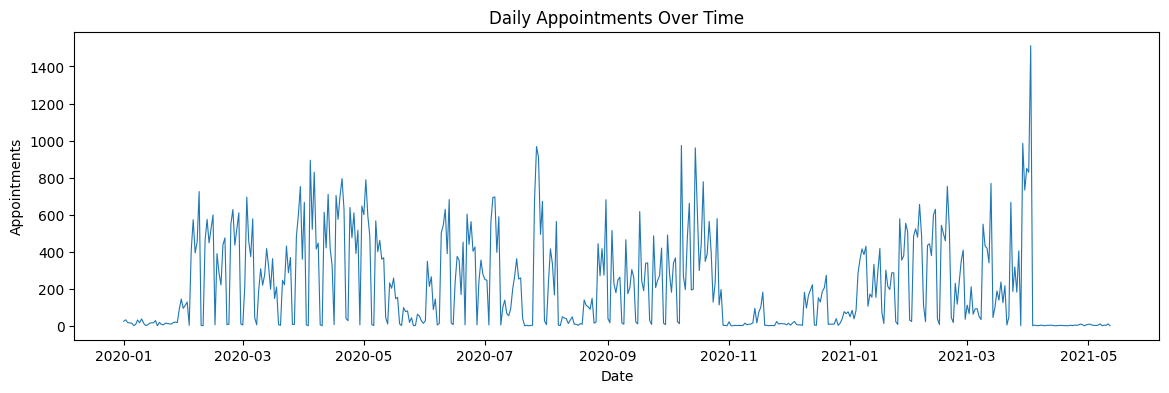

count     498.000000
mean      220.066265
std       245.803633
min         1.000000
25%        10.000000
50%       126.500000
75%       393.250000
max      1512.000000
Name: total_appointments, dtype: float64


In [49]:
# to visualise daily appointments over time

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(daily['date'], daily['total_appointments'], linewidth=0.8)
plt.title('Daily Appointments Over Time')
plt.xlabel('Date')
plt.ylabel('Appointments')
plt.show()

print(daily['total_appointments'].describe())

In [50]:
# to add lag features

d = daily.copy()

d['day_of_week'] = d['date'].dt.dayofweek
d['month'] = d['date'].dt.month
d['year'] = d['date'].dt.year
d['is_weekend'] = (d['day_of_week'] >= 5).astype(int)

d['lag_1'] = d['total_appointments'].shift(1)
d['lag_7'] = d['total_appointments'].shift(7)
d['lag_14'] = d['total_appointments'].shift(14)

print(d.shape)

(498, 31)


In [51]:
# to remove weekends and bad date ranges

d = d[d['date'].dt.dayofweek < 5].copy()
d = d[d['date'] < '2021-04-01'].copy()
d = d[d['date'] >= '2020-01-01'].copy()
d = d.dropna().reset_index(drop=True)

print('total days:', len(d))

split = int(len(d) * 0.8)
train = d.iloc[:split]
test = d.iloc[split:]
# train-test split

print('train:', len(train), 'test:', len(test))

features = [c for c in d.columns if c not in ['date', 'total_appointments']]

X_train = train[features]
y_train = train['total_appointments']
X_test = test[features]
y_test = test['total_appointments']

total days: 316
train: 252 test: 64


In [52]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

predictions = np.clip(model.predict(X_test), 0, None)

In [53]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
mape = np.mean(np.abs((y_test.values - predictions) / y_test.values)) * 100

print('RMSE:', round(rmse, 2))
print('MAE:', round(mae, 2))
print('MAPE:', round(mape, 2), '%')
print('R2:', round(r2, 4))

RMSE: 37.67
MAE: 18.81
MAPE: 6.27 %
R2: 0.9721


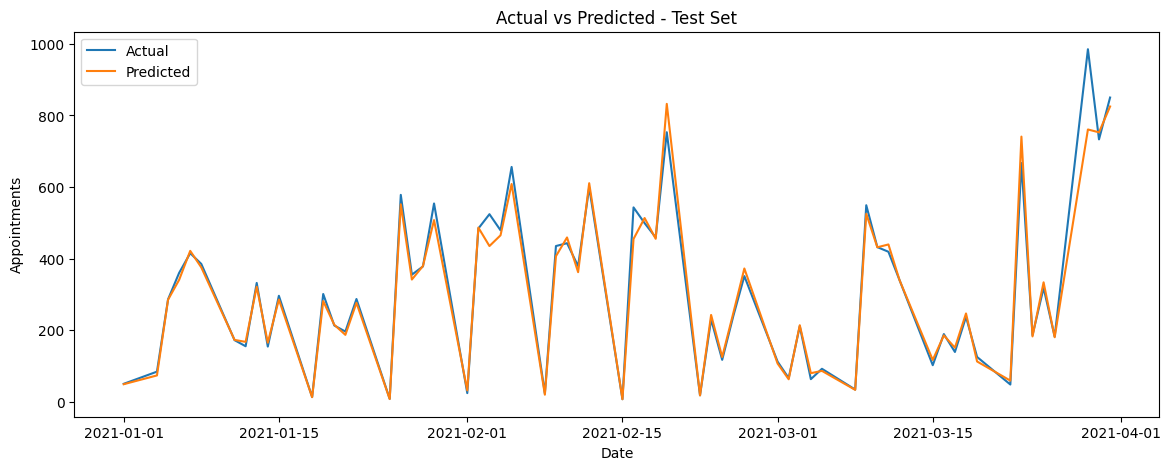

In [54]:
# plot test set predictions

plt.figure(figsize=(14, 5))
plt.plot(test['date'].values, y_test.values, label='Actual')
plt.plot(test['date'].values, predictions, label='Predicted')
plt.title('Actual vs Predicted - Test Set')
plt.xlabel('Date')
plt.ylabel('Appointments')
plt.legend()
plt.show()

In [55]:
import joblib
import os

os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/demand_model.pkl')
joblib.dump(features, 'model/demand_feature_cols.pkl')
d.to_csv('model/demand_history.csv', index=False)
print('overall demand model saved!')

overall demand model saved!


## Specialty specific Demand Forecasting


In [56]:
specialties = ['psychotherapy', 'speech therapy', 'physiotherapy',
               'occupational therapy', 'pedagogo', 'enf']

print('specialties:', specialties)

df_spec = df[df['specialty'].isin(specialties)].copy()
print('rows after filtering:', len(df_spec))

specialties: ['psychotherapy', 'speech therapy', 'physiotherapy', 'occupational therapy', 'pedagogo', 'enf']
rows after filtering: 88507


In [57]:
# group by date and specialty together and aggregate

spec_daily_agg = df_spec.groupby(['appointment_date_continuous', 'specialty']).agg(
    total_appointments = ('no_show', 'count'),
    avg_temp = ('average_temp_day', 'mean'),
    avg_rain = ('average_rain_day', 'mean'),
    rainy_day_before = ('rainy_day_before', 'max'),
    pct_elderly = ('over_60_years_old', 'mean'),
    pct_hypertension = ('Hipertension', 'mean'),
    pct_diabetes = ('Diabetes', 'mean'),
    pct_sms = ('SMS_received', 'mean'),
).reset_index()

spec_daily_agg = spec_daily_agg.rename(columns={'appointment_date_continuous': 'date'})
spec_daily_agg = spec_daily_agg.sort_values(['specialty', 'date']).reset_index(drop=True)

spec_daily_agg['specialty_encoded'] = spec_daily_agg['specialty'].astype('category').cat.codes
specialty_mapping = dict(enumerate(spec_daily_agg['specialty'].astype('category').cat.categories))
# to encode specialty as number so model can use it

print('specialty encoding:')
for k, v in specialty_mapping.items():
    print(' ', k, '-', v)

spec_daily_agg.head()

specialty encoding:
  0 - enf
  1 - occupational therapy
  2 - pedagogo
  3 - physiotherapy
  4 - psychotherapy
  5 - speech therapy


,date,specialty,total_appointments,avg_temp,avg_rain,rainy_day_before,pct_elderly,pct_hypertension,pct_diabetes,pct_sms,specialty_encoded
0,2020-01-04,enf,1,19.77,0.000,1,0.0,0.0,0.0,0.0,0
1,2020-01-07,enf,1,22.38,0.010,1,1.0,1.0,0.0,0.0,0
2,2020-01-11,enf,1,21.16,0.050,1,0.0,0.0,0.0,1.0,0
3,2020-01-14,enf,2,20.26,0.005,1,0.5,0.0,0.0,0.5,0
4,2020-01-15,enf,1,21.86,0.000,1,0.0,0.0,0.0,0.0,0


In [58]:
# add features per specialty separately to avoid lag leakage between specialties

all_spec_data = []

for spec in specialties:
    s = spec_daily_agg[spec_daily_agg['specialty'] == spec].copy()
    s = s.sort_values('date').reset_index(drop=True)

    s['day_of_week'] = s['date'].dt.dayofweek
    s['month'] = s['date'].dt.month
    s['year'] = s['date'].dt.year
    s['is_weekend'] = (s['day_of_week'] >= 5).astype(int)

    s['lag_1'] = s['total_appointments'].shift(1)
    s['lag_7'] = s['total_appointments'].shift(7)
    s['lag_14'] = s['total_appointments'].shift(14)

    s = s[s['date'].dt.dayofweek < 5].copy()
    s = s[s['date'] < '2021-04-01'].copy()
    s = s[s['date'] >= '2020-01-01'].copy()
    s = s.dropna().reset_index(drop=True)
    # to remove weekends and bad dates where there are 0 or very less appointments

    all_spec_data.append(s)

spec_feat = pd.concat(all_spec_data).reset_index(drop=True)
spec_feat = spec_feat.sort_values('date').reset_index(drop=True)

print('total rows:', len(spec_feat))
spec_feat.head()

total rows: 1594


,date,specialty,total_appointments,avg_temp,avg_rain,rainy_day_before,pct_elderly,pct_hypertension,pct_diabetes,pct_sms,specialty_encoded,day_of_week,month,year,is_weekend,lag_1,lag_7,lag_14
0,2020-01-15,psychotherapy,4,19.400000,0.155000,1,0.0,0.0,0.0,0.500000,4,2,1,2020,0,2.0,10.0,7.0
1,2020-01-16,psychotherapy,3,21.336667,0.046667,1,0.0,0.0,0.0,0.666667,4,3,1,2020,0,4.0,4.0,12.0
2,2020-01-17,physiotherapy,5,18.760000,0.130000,1,0.0,0.0,0.0,0.200000,3,4,1,2020,0,2.0,2.0,6.0
3,2020-01-17,speech therapy,3,22.226667,0.536667,1,0.0,0.0,0.0,0.000000,5,4,1,2020,0,4.0,4.0,6.0
4,2020-01-17,psychotherapy,6,20.243333,0.485000,1,0.0,0.0,0.0,0.166667,4,4,1,2020,0,3.0,13.0,3.0


In [59]:
# train test split

split_s = int(len(spec_feat) * 0.8)
train_s = spec_feat.iloc[:split_s]
test_s = spec_feat.iloc[split_s:]

print('train:', len(train_s), 'test:', len(test_s))

DROP_S = ['date', 'total_appointments', 'specialty']
spec_features = [c for c in spec_feat.columns if c not in DROP_S]

X_train_s = train_s[spec_features]
y_train_s = train_s['total_appointments']
X_test_s = test_s[spec_features]
y_test_s = test_s['total_appointments']

print('features:', spec_features)

train: 1275 test: 319
features: ['avg_temp', 'avg_rain', 'rainy_day_before', 'pct_elderly', 'pct_hypertension', 'pct_diabetes', 'pct_sms', 'specialty_encoded', 'day_of_week', 'month', 'year', 'is_weekend', 'lag_1', 'lag_7', 'lag_14']


In [60]:
spec_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

spec_model.fit(X_train_s, y_train_s)

spec_predictions = np.clip(spec_model.predict(X_test_s), 0, None)

In [61]:
rmse_s = np.sqrt(mean_squared_error(y_test_s, spec_predictions))
mae_s = mean_absolute_error(y_test_s, spec_predictions)
r2_s = r2_score(y_test_s, spec_predictions)
mape_s = np.mean(np.abs((y_test_s.values - spec_predictions) / (y_test_s.values + 1))) * 100

print('RMSE:', round(rmse_s, 2))
print('MAE:', round(mae_s, 2))
print('MAPE:', round(mape_s, 2), '%')
print('R2:', round(r2_s, 4))
print()

print('Per specialty breakdown:')
for spec in specialties:
    mask = test_s['specialty'] == spec
    if mask.sum() == 0:
        continue
    actual = y_test_s[mask].values
    pred = spec_predictions[mask]
    r2_spec = r2_score(actual, pred)
    mape_spec = np.mean(np.abs((actual - pred) / (actual + 1))) * 100
    print(spec, '- MAPE:', round(mape_spec, 1), '% R2:', round(r2_spec, 4))

RMSE: 24.46
MAE: 14.49
MAPE: 42.35 %
R2: 0.7504

Per specialty breakdown:
psychotherapy - MAPE: 44.6 % R2: 0.5846
speech therapy - MAPE: 47.2 % R2: 0.7225
physiotherapy - MAPE: 51.2 % R2: 0.5159
occupational therapy - MAPE: 31.6 % R2: 0.8164
pedagogo - MAPE: 42.4 % R2: 0.5227
enf - MAPE: 35.5 % R2: 0.2464


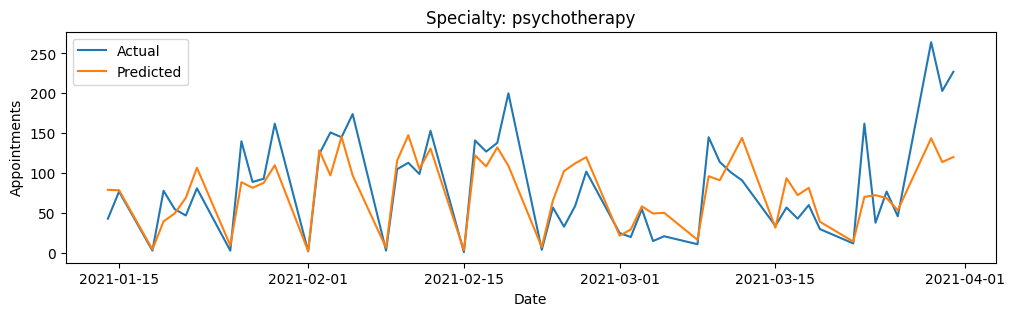

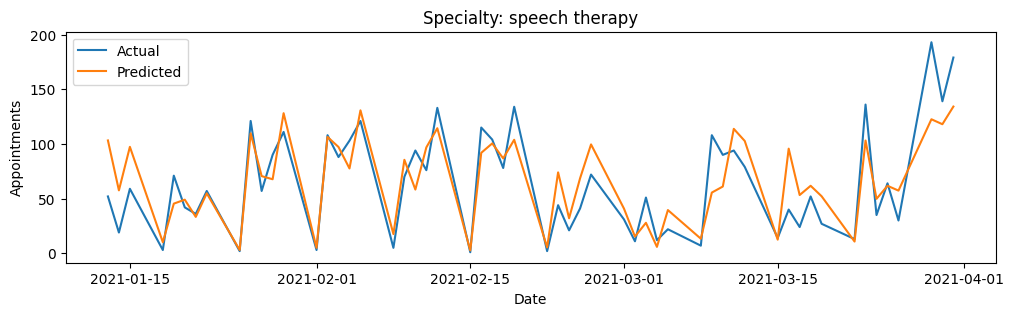

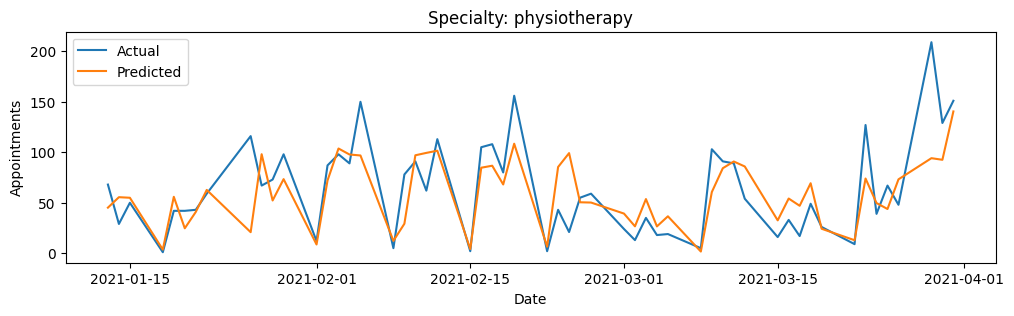

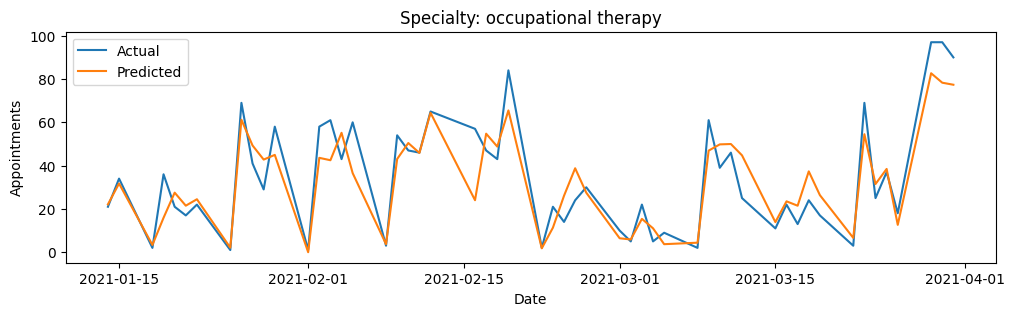

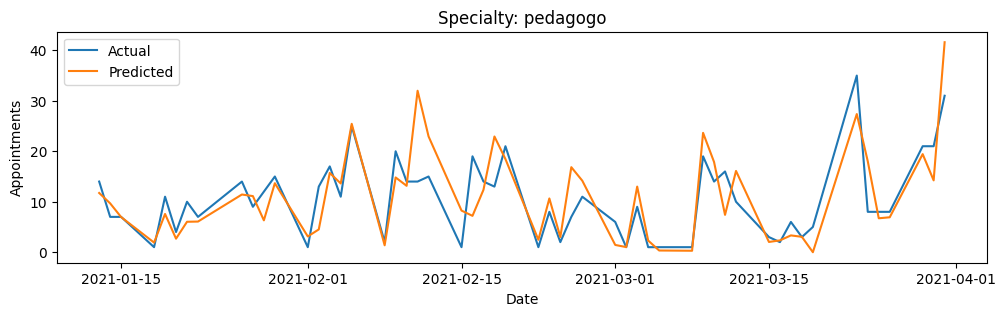

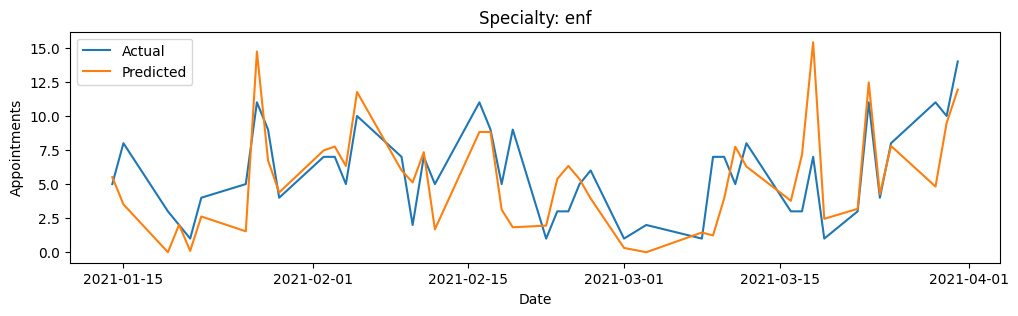

In [62]:
# plot predictions per specialty

for spec in specialties:
    mask = test_s['specialty'] == spec
    if mask.sum() == 0:
        continue
    actual = y_test_s[mask].values
    pred = spec_predictions[mask]
    dates = test_s[mask]['date'].values

    plt.figure(figsize=(12, 3))
    plt.plot(dates, actual, label='Actual')
    plt.plot(dates, pred, label='Predicted')
    plt.title('Specialty: ' + spec)
    plt.xlabel('Date')
    plt.ylabel('Appointments')
    plt.legend()
    plt.show()

In [63]:
joblib.dump(spec_model, 'model/specialty_model.pkl')
joblib.dump(spec_features, 'model/specialty_model_features.pkl')
joblib.dump(specialty_mapping, 'model/specialty_mapping.pkl')
spec_feat.to_csv('model/specialty_history.csv', index=False)

print('specialty model saved!')

specialty model saved!


In [64]:
# I had an issue where number of appoinments werent correctly displayed, hence i needed average appointments
# that issue was because of streamlit

import pandas as pd

hist = pd.read_csv('model/demand_history.csv')
print(hist.shape)
print(hist[['date', 'total_appointments']].tail(10))
print('max appointments:', hist['total_appointments'].max())
print('avg appointments:', hist['total_appointments'].mean())



(316, 31)
           date  total_appointments
306  2021-03-18                 237
307  2021-03-19                 125
308  2021-03-22                  48
309  2021-03-23                 667
310  2021-03-24                 186
311  2021-03-25                 318
312  2021-03-26                 182
313  2021-03-29                 985
314  2021-03-30                 733
315  2021-03-31                 850
max appointments: 985
avg appointments: 249.6740506329114


In [65]:
# feature averages for streamlit

feature_defaults = d[features].mean().to_dict()
joblib.dump(feature_defaults, 'model/demand_feature_defaults.pkl')
print('feature defaults saved!')
print(feature_defaults)


feature defaults saved!
{'avg_temp': 20.27562836808615, 'avg_rain': 0.18473523303937497, 'rainy_day_before': 1.0, 'pct_elderly': 0.07369616823388293, 'pct_hypertension': 0.060903222174877675, 'pct_diabetes': 0.02075747899231694, 'pct_sms': 0.3097467456930858, 'spec_unknown': 45.949367088607595, 'spec_assist': 1.4177215189873418, 'spec_enf': 3.7848101265822787, 'spec_occupational_therapy': 25.7626582278481, 'spec_pedagogo': 8.221518987341772, 'spec_physiotherapy': 48.0253164556962, 'spec_psychotherapy': 65.0632911392405, 'spec_sem_especialidade': 0.7088607594936709, 'spec_speech_therapy': 50.74050632911393, 'place_b._camboriu': 13.69620253164557, 'place_camboriu': 12.60126582278481, 'place_itajaí': 46.88291139240506, 'place_navegantes': 8.95253164556962, 'place_unknown': 26.329113924050635, 'place_other': 141.2120253164557, 'day_of_week': 2.0, 'month': 5.784810126582278, 'year': 2020.2025316455697, 'is_weekend': 0.0, 'lag_1': 233.13291139240508, 'lag_7': 240.3006329113924, 'lag_14': 236